### **WEBSOCKET**

In [25]:
import json
import websocket

# Websocket conection creation
ws = websocket.create_connection("wss://www.deribit.com/ws/api/v2")

# Request creation
req1 = {
    "jsonrpc": "2.0",                       # Protocol version
    "id": 1,                                # Id of the request
    "method": "public/get_instruments",     # Method (lsit of finantial instruments)
    "params": {                             # "Prove all the BTC options that arent expired"
        "currency": "BTC",
        "kind": "option",
        "expired": False
    }
}

In [26]:
# Dictionary -> JSON
ws.send(json.dumps(req1))

# Recive respond -> ws.recv() [Server respond] // json.loads() [JSON to dict]
instruments_resp = json.loads(ws.recv())

#Extract instruments
instruments = instruments_resp["result"]
print(f"Opciones BTC activas: {len(instruments)}")

Opciones BTC activas: 858


In [27]:
# 2) Traer resumen de mercado de toda la chain
req2 = {
    "jsonrpc": "2.0",
    "id": 2,
    "method": "public/get_book_summary_by_currency",
    "params": {
        "currency": "BTC",
        "kind": "option"
    }
}
ws.send(json.dumps(req2))
summary_resp = json.loads(ws.recv())

chain = summary_resp["result"]

In [28]:
contract = "BTC-10APR26"

contract_chain = [
    x for x in chain
    if x["instrument_name"].startswith(contract)
]

print(f"Opciones para {contract}: {len(contract_chain)}")

for x in contract_chain[:10]:
    print(
        x["instrument_name"],
        x.get("bid_price"),
        x.get("ask_price"),
        x.get("mark_price"),
        x.get("open_interest"),
    )

Opciones para BTC-10APR26: 58
BTC-10APR26-64000-P 0.0001 0.0003 0.00024475 1558.8
BTC-10APR26-62000-C 0.1015 0.156 0.13497858 0.2
BTC-10APR26-74000-C 0.0021 0.0026 0.00230572 1599.8
BTC-10APR26-62000-P 0.0001 0.0002 0.00014891 1023.4
BTC-10APR26-64000-C 0.106 0.109 0.10716571 7.0
BTC-10APR26-71000-P 0.0075 0.0085 0.00794055 213.3
BTC-10APR26-68500-C 0.0445 0.0475 0.04551649 7.0
BTC-10APR26-68500-P 0.0012 0.0015 0.00139015 65.8
BTC-10APR26-83000-P 0.1235 0.1925 0.15824332 0.0
BTC-10APR26-72500-P 0.0175 0.0195 0.01865955 0.3


In [29]:
import pandas as pd

df = pd.DataFrame(contract_chain)[["instrument_name",
    "bid_price",
    "ask_price",
    "mark_price",
    "open_interest",
    "volume",
    "underlying_price",]]

In [30]:
df[["base", "expiry", "strike", "option_type"]] = df["instrument_name"].str.split("-", expand=True)

df["strike"] = pd.to_numeric(df["strike"], errors="coerce")

In [31]:
df_calls = df[df["option_type"] == "C"].copy()

df_calls["mid_price"] = (df["bid_price"] + df["ask_price"]) / 2
df_calls["spread"] = df_calls["ask_price"] - df["bid_price"]

df_calls = df_calls[
    (df_calls["bid_price"] > 0) &
    (df_calls["ask_price"] > 0) &
    (df_calls["mid_price"] > 0)
].copy()


df_calls = df_calls.sort_values("strike").reset_index(drop=True)

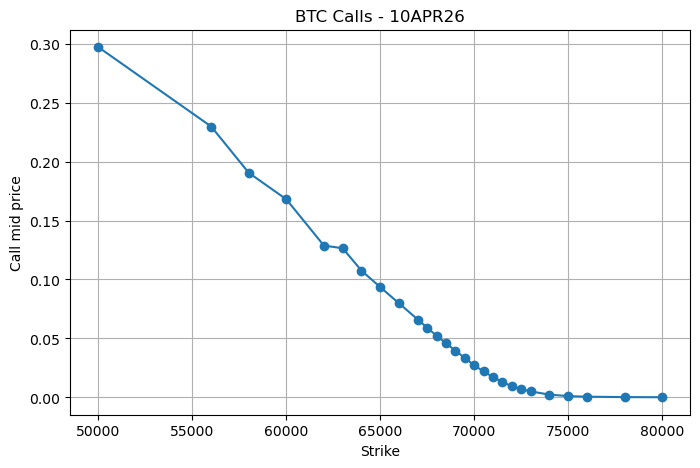

In [32]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))
plt.plot(df_calls["strike"], df_calls["mid_price"], marker="o")
plt.xlabel("Strike")
plt.ylabel("Call mid price")
plt.title("BTC Calls - 10APR26")
plt.grid(True)
plt.show()

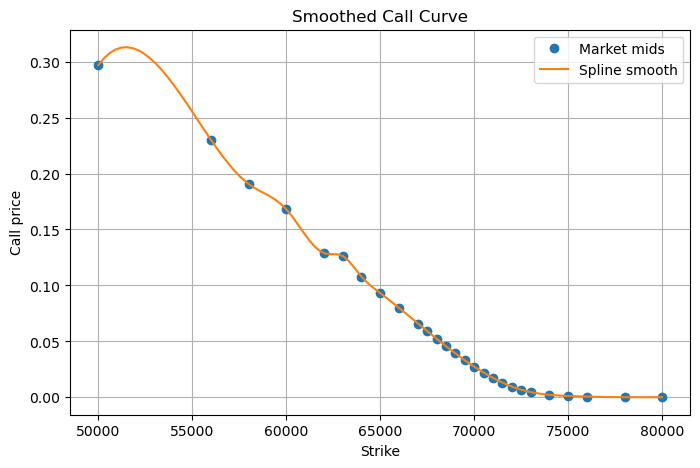

In [33]:
import numpy as np
from scipy.interpolate import UnivariateSpline
import matplotlib.pyplot as plt

K = df_calls["strike"].values.astype(float)
C = df_calls["mid_price"].values.astype(float)

spline = UnivariateSpline(K, C, s=1e-6)  # luego ajustamos s si hace falta

K_grid = np.linspace(K.min(), K.max(), 100)
C_smooth = spline(K_grid)

plt.figure(figsize=(8,5))
plt.plot(K, C, "o", label="Market mids")
plt.plot(K_grid, C_smooth, label="Spline smooth")
plt.xlabel("Strike")
plt.ylabel("Call price")
plt.title("Smoothed Call Curve")
plt.grid(True)
plt.legend()
plt.show()

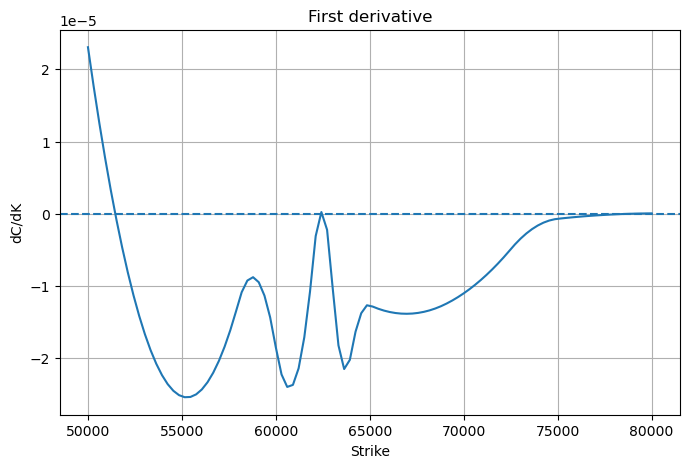

In [34]:
dC = spline.derivative(1)(K_grid)

plt.figure(figsize=(8,5))
plt.plot(K_grid, dC)
plt.axhline(0, linestyle="--")
plt.xlabel("Strike")
plt.ylabel("dC/dK")
plt.title("First derivative")
plt.grid(True)
plt.show()

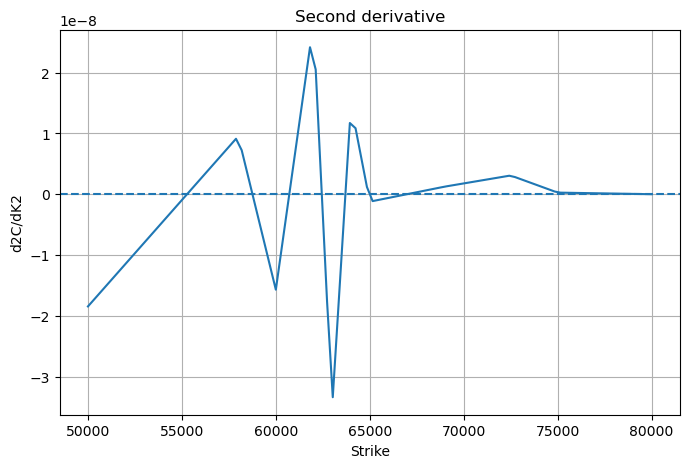

In [35]:
d2C = spline.derivative(2)(K_grid)

plt.figure(figsize=(8,5))
plt.plot(K_grid, d2C)
plt.axhline(0, linestyle="--")
plt.xlabel("Strike")
plt.ylabel("d2C/dK2")
plt.title("Second derivative")
plt.grid(True)
plt.show()

In [36]:
expirations = sorted({
    x["instrument_name"].split("-")[1]
    for x in instruments
})
print(expirations)


['10APR26', '11APR26', '12APR26', '17APR26', '24APR26', '25DEC26', '25SEP26', '26JUN26', '26MAR27', '29MAY26', '9APR26']


##### **Cambio a BTC_USDC linear options**

A partir de aqui trabajamos solo con opciones lineales `BTC_USDC`.
La idea es: listar expiries disponibles, elegir una sola expiry y construir la curva usando un snapshot limpio para esa maturity.

In [37]:
import json
import pandas as pd
import websocket

ws = websocket.create_connection("wss://www.deribit.com/ws/api/v2")

req = {
    "jsonrpc": "2.0",
    "id": 1,
    "method": "public/get_instruments",
    "params": {
        "currency": "USDC",
        "kind": "option",
        "expired": False,
    },
}

ws.send(json.dumps(req))
resp = json.loads(ws.recv())
usdc_instruments = resp["result"]

df_inst = pd.DataFrame(usdc_instruments)
df_inst = df_inst[
    (df_inst["base_currency"] == "BTC")
    & (df_inst["counter_currency"] == "USDC")
    & (df_inst["instrument_type"] == "linear")
].copy()

df_inst["expiry_dt"] = pd.to_datetime(df_inst["expiration_timestamp"], unit="ms", utc=True)
df_inst["expiry_label"] = df_inst["expiry_dt"].dt.strftime("%d%b%y").str.upper()
df_inst["expiry_str"] = df_inst["expiry_dt"].dt.strftime("%Y-%m-%d %H:%M:%S UTC")

print(df_inst[["instrument_name", "instrument_type", "base_currency", "counter_currency"]].head())
print(sorted(df_inst["expiry_str"].unique()))


            instrument_name instrument_type base_currency counter_currency
58  BTC_USDC-9APR26-59000-C          linear           BTC             USDC
59  BTC_USDC-9APR26-59000-P          linear           BTC             USDC
60  BTC_USDC-9APR26-60000-C          linear           BTC             USDC
61  BTC_USDC-9APR26-60000-P          linear           BTC             USDC
62  BTC_USDC-9APR26-61000-C          linear           BTC             USDC
['2026-04-09 08:00:00 UTC', '2026-04-10 08:00:00 UTC', '2026-04-11 08:00:00 UTC', '2026-04-12 08:00:00 UTC', '2026-04-17 08:00:00 UTC', '2026-04-24 08:00:00 UTC', '2026-05-29 08:00:00 UTC', '2026-06-26 08:00:00 UTC']


Construimos la chain completa, elegimos una sola expiry y nos quedamos con calls limpias para esa maturity.

In [38]:
req2 = {
    "jsonrpc": "2.0",
    "id": 2,
    "method": "public/get_book_summary_by_currency",
    "params": {
        "currency": "USDC",
        "kind": "option",
    },
}

ws.send(json.dumps(req2))
summary_resp = json.loads(ws.recv())

df_chain = pd.DataFrame(summary_resp["result"])
df_chain = df_chain[df_chain["instrument_name"].str.startswith("BTC_USDC-")].copy()

df_chain[["base", "expiry", "strike", "option_type"]] = (
    df_chain["instrument_name"].str.split("-", expand=True)
)

df_chain["strike"] = pd.to_numeric(df_chain["strike"], errors="coerce")
df_chain = df_chain[[
    "instrument_name",
    "bid_price",
    "ask_price",
    "mark_price",
    "open_interest",
    "volume",
    "underlying_price",
    "base",
    "expiry",
    "strike",
    "option_type",
]].copy()

expiries = sorted(df_chain["expiry"].dropna().unique())
print(expiries)

selected_expiry = "10APR26"

df_expiry = df_chain[df_chain["expiry"] == selected_expiry].copy()
df_calls = df_expiry[df_expiry["option_type"] == "C"].copy()

df_calls["mid_price"] = (df_calls["bid_price"] + df_calls["ask_price"]) / 2
df_calls["spread"] = df_calls["ask_price"] - df_calls["bid_price"]

df_calls = df_calls[
    (df_calls["bid_price"] > 0)
    & (df_calls["ask_price"] > 0)
    & (df_calls["mid_price"] > 0)
].copy()

df_calls = df_calls.sort_values("strike").reset_index(drop=True)
df_calls


['10APR26', '11APR26', '12APR26', '17APR26', '24APR26', '26JUN26', '29MAY26', '9APR26']


,instrument_name,bid_price,ask_price,mark_price,open_interest,volume,underlying_price,base,expiry,strike,option_type,mid_price,spread
0,BTC_USDC-10APR26-70000-C,5.0,2400.0,1946.853083,12.30,1.40,71659.05,BTC_USDC,10APR26,70000,C,1202.5,2395.0
1,BTC_USDC-10APR26-71000-C,1140.0,1360.0,1229.032662,12.26,6.67,71659.05,BTC_USDC,10APR26,71000,C,1250.0,220.0
2,BTC_USDC-10APR26-71500-C,915.0,975.0,941.464588,0.00,0.00,71659.05,BTC_USDC,10APR26,71500,C,945.0,60.0
3,BTC_USDC-10APR26-72000-C,675.0,725.0,697.011111,2.35,1.49,71659.22,BTC_USDC,10APR26,72000,C,700.0,50.0
4,BTC_USDC-10APR26-72500-C,480.0,520.0,498.141497,0.00,0.00,71659.22,BTC_USDC,10APR26,72500,C,500.0,40.0
5,BTC_USDC-10APR26-73000-C,335.0,365.0,354.844936,4.43,0.22,71659.22,BTC_USDC,10APR26,73000,C,350.0,30.0
6,BTC_USDC-10APR26-74000-C,155.0,175.0,164.720500,2.60,0.55,71659.05,BTC_USDC,10APR26,74000,C,165.0,20.0
7,BTC_USDC-10APR26-75000-C,70.0,90.0,76.776634,1.37,1.10,71659.05,BTC_USDC,10APR26,75000,C,80.0,20.0
8,BTC_USDC-10APR26-76000-C,35.0,50.0,41.539584,30.12,0.72,71659.05,BTC_USDC,10APR26,76000,C,42.5,15.0
9,BTC_USDC-10APR26-78000-C,10.0,25.0,18.126367,0.10,0.00,71659.05,BTC_USDC,10APR26,78000,C,17.5,15.0


In [39]:
ws.close()

### **SVI sobre una expiry fija**

La idea ahora es subir de nivel metodologico:

1. usar una sola expiry,
2. construir una smile en volatilidad implicita,
3. ajustar un `raw SVI` sobre total variance,
4. reconstruir una curva suave de calls,
5. y derivar sobre esa curva limpia.

In [40]:
import math
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import brentq, least_squares
from scipy.stats import norm


def bs_call_price(spot, strike, tau, vol, rate=0.0):
    if tau <= 0:
        return max(spot - strike, 0.0)
    if vol <= 0:
        return max(spot - strike * math.exp(-rate * tau), 0.0)

    sqrt_tau = math.sqrt(tau)
    d1 = (math.log(spot / strike) + (rate + 0.5 * vol * vol) * tau) / (vol * sqrt_tau)
    d2 = d1 - vol * sqrt_tau
    return spot * norm.cdf(d1) - strike * math.exp(-rate * tau) * norm.cdf(d2)


def bs_put_price(spot, strike, tau, vol, rate=0.0):
    call = bs_call_price(spot, strike, tau, vol, rate)
    return call - spot + strike * math.exp(-rate * tau)


def implied_vol_from_price(price, spot, strike, tau, option_type, rate=0.0):
    if tau <= 0 or price <= 0 or spot <= 0 or strike <= 0:
        return np.nan

    intrinsic_call = max(spot - strike * math.exp(-rate * tau), 0.0)
    intrinsic_put = max(strike * math.exp(-rate * tau) - spot, 0.0)

    if option_type == "C":
        if price <= intrinsic_call:
            return np.nan
        objective = lambda vol: bs_call_price(spot, strike, tau, vol, rate) - price
    else:
        if price <= intrinsic_put:
            return np.nan
        objective = lambda vol: bs_put_price(spot, strike, tau, vol, rate) - price

    try:
        return brentq(objective, 1e-6, 5.0)
    except ValueError:
        return np.nan


def svi_raw(k, a, b, rho, m, sigma):
    return a + b * (rho * (k - m) + np.sqrt((k - m) ** 2 + sigma ** 2))


def fit_svi(k, w_obs, weights=None):
    if weights is None:
        weights = np.ones_like(w_obs)

    w_floor = max(float(np.nanmin(w_obs)) * 0.5, 1e-8)
    x0 = np.array([w_floor, 0.2, 0.0, 0.0, 0.2])
    lower = np.array([-1.0, 1e-8, -0.999, -5.0, 1e-6])
    upper = np.array([5.0, 10.0, 0.999, 5.0, 5.0])

    def residuals(params):
        a, b, rho, m, sigma = params
        w_fit = svi_raw(k, a, b, rho, m, sigma)
        penalty = np.sqrt(1e4) * np.minimum(w_fit - 1e-10, 0.0)
        return np.concatenate([weights * (w_fit - w_obs), penalty])

    result = least_squares(residuals, x0=x0, bounds=(lower, upper), max_nfev=20000)
    return result


In [41]:
rate = 0.0
selected_expiry_label = pd.to_datetime(selected_expiry, format="%d%b%y").strftime("%d%b%y").upper()
valuation_dt = globals().get("chain_snapshot_dt", pd.Timestamp.now(tz="UTC"))

expiry_matches = df_inst.loc[df_inst["expiry_label"] == selected_expiry_label, "expiry_dt"].dropna()
if expiry_matches.empty:
    available_expiries = sorted(df_inst["expiry_label"].dropna().unique())
    raise ValueError(f"selected_expiry={selected_expiry} not found in df_inst. Available: {available_expiries}")

expiry_dt = expiry_matches.iloc[0]
tau = max((expiry_dt - valuation_dt).total_seconds() / (365.0 * 24.0 * 3600.0), 1e-6)
spot = float(df_expiry["underlying_price"].median())

df_parity = df_expiry.copy()
df_parity["mid_price"] = (df_parity["bid_price"] + df_parity["ask_price"]) / 2.0
df_parity = df_parity[
    (df_parity["bid_price"] > 0)
    & (df_parity["ask_price"] > 0)
    & (df_parity["mid_price"] > 0)
].copy()

parity_pairs = (
    df_parity.pivot_table(index="strike", columns="option_type", values="mid_price", aggfunc="first")
    .dropna(subset=["C", "P"])
    .reset_index()
)

if not parity_pairs.empty:
    parity_pairs["distance_to_spot"] = (parity_pairs["strike"] - spot).abs()
    parity_pairs = parity_pairs.sort_values("distance_to_spot")
    parity_sample = parity_pairs.head(min(5, len(parity_pairs))).copy()
    forward = float((parity_sample["strike"] + np.exp(rate * tau) * (parity_sample["C"] - parity_sample["P"])).median())
else:
    forward = spot * math.exp(rate * tau)

df_svi = df_expiry.copy()
df_svi["mid_price"] = (df_svi["bid_price"] + df_svi["ask_price"]) / 2.0
df_svi["spread"] = df_svi["ask_price"] - df_svi["bid_price"]
df_svi["spread_pct_mid"] = df_svi["spread"] / df_svi["mid_price"]

df_svi = df_svi[
    (df_svi["bid_price"] > 0)
    & (df_svi["ask_price"] > 0)
    & (df_svi["mid_price"] > 0)
    & (df_svi["strike"] > 0)
].copy()

if "mark_iv" in df_svi.columns:
    df_svi["iv_input"] = df_svi["mark_iv"].astype(float)
    if df_svi["iv_input"].dropna().median() > 3:
        df_svi["iv_input"] = df_svi["iv_input"] / 100.0
else:
    df_svi["iv_input"] = df_svi.apply(
        lambda row: implied_vol_from_price(
            price=float(row["mid_price"]),
            spot=spot,
            strike=float(row["strike"]),
            tau=tau,
            option_type=row["option_type"],
            rate=rate,
        ),
        axis=1,
    )

df_svi = df_svi[(df_svi["iv_input"] > 0) & (df_svi["iv_input"] < 5)].copy()

# Para una smile mas estable usamos OTM calls y OTM puts respecto al forward.
df_svi = df_svi[
    ((df_svi["option_type"] == "C") & (df_svi["strike"] >= forward))
    | ((df_svi["option_type"] == "P") & (df_svi["strike"] < forward))
].copy()

# Filtro sencillo de calidad para quitar quotes demasiado ruidosas.
df_svi = df_svi[
    (df_svi["spread_pct_mid"] < 0.8)
    & ((df_svi["volume"] > 0) | (df_svi["open_interest"] > 0))
].copy()

df_svi["log_moneyness"] = np.log(df_svi["strike"] / forward)
df_svi["total_variance"] = (df_svi["iv_input"] ** 2) * tau
df_svi = df_svi.sort_values("strike").reset_index(drop=True)

weights = np.sqrt(df_svi["open_interest"].fillna(0.0) + df_svi["volume"].fillna(0.0) + 1.0).to_numpy()
k_obs = df_svi["log_moneyness"].to_numpy(dtype=float)
w_obs = df_svi["total_variance"].to_numpy(dtype=float)

print(f"selected_expiry = {selected_expiry}")
print(f"expiry_dt = {expiry_dt}")
print(f"tau_years = {tau:.6f}")
print(f"spot_used = {spot:.2f}")
print(f"quotes_for_svi = {len(df_svi)}")

df_svi[["instrument_name", "option_type", "strike", "mid_price", "iv_input", "log_moneyness", "total_variance"]].head()

selected_expiry = 10APR26
expiry_dt = 2026-04-10 08:00:00+00:00
tau_years = 0.005287
spot_used = 71659.05
quotes_for_svi = 15


,instrument_name,option_type,strike,mid_price,iv_input,log_moneyness,total_variance
0,BTC_USDC-10APR26-65000-P,P,65000,20.0,0.636435,-0.097668,0.002142
1,BTC_USDC-10APR26-66000-P,P,66000,27.5,0.578058,-0.082400,0.001767
2,BTC_USDC-10APR26-67000-P,P,67000,42.5,0.527061,-0.067362,0.001469
3,BTC_USDC-10APR26-67500-P,P,67500,55.0,0.504074,-0.059927,0.001343
4,BTC_USDC-10APR26-68000-P,P,68000,70.0,0.478287,-0.052547,0.001209


SVI fitted params
{'a': -0.05332020093140555, 'b': 0.5866181046873337, 'rho': -0.9057271110016418, 'm': -0.4620056195437755, 'sigma': 0.21794106910650365}
optimizer_success = True
optimizer_message = `ftol` termination condition is satisfied.


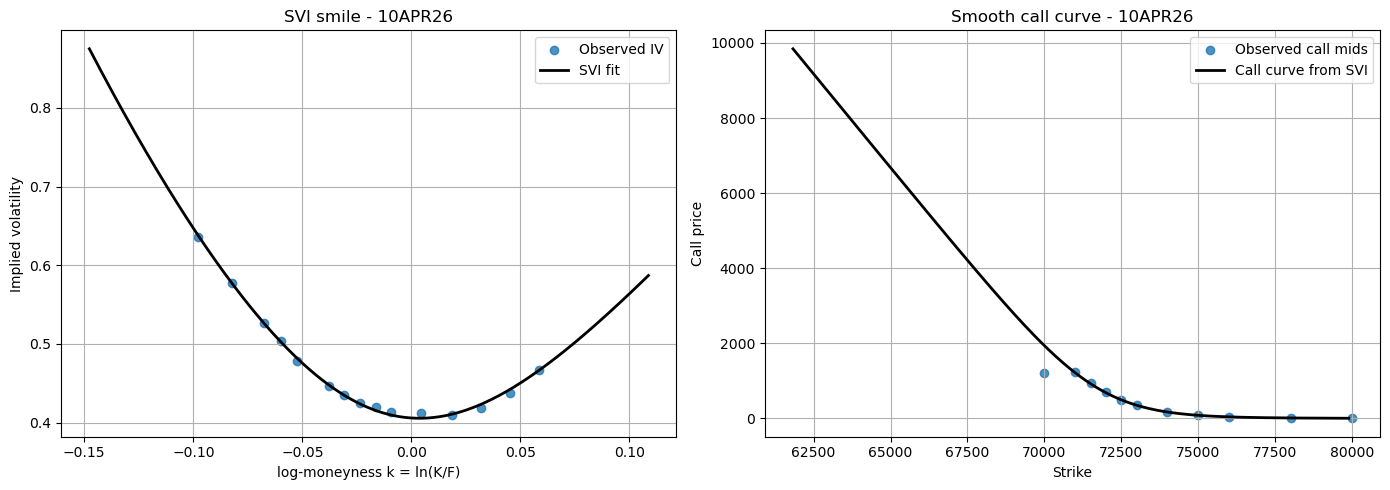

In [42]:
svi_result = fit_svi(k_obs, w_obs, weights=weights)
a_fit, b_fit, rho_fit, m_fit, sigma_fit = svi_result.x

print("SVI fitted params")
print({
    "a": a_fit,
    "b": b_fit,
    "rho": rho_fit,
    "m": m_fit,
    "sigma": sigma_fit,
})
print("optimizer_success =", svi_result.success)
print("optimizer_message =", svi_result.message)

k_grid = np.linspace(k_obs.min() - 0.05, k_obs.max() + 0.05, 300)
w_grid = svi_raw(k_grid, a_fit, b_fit, rho_fit, m_fit, sigma_fit)
iv_grid = np.sqrt(np.maximum(w_grid / tau, 1e-12))
K_grid = forward * np.exp(k_grid)

call_svi_grid = np.array([
    bs_call_price(spot, strike, tau, vol, rate)
    for strike, vol in zip(K_grid, iv_grid)
])

df_svi["w_fit"] = svi_raw(df_svi["log_moneyness"].to_numpy(), a_fit, b_fit, rho_fit, m_fit, sigma_fit)
df_svi["iv_fit"] = np.sqrt(np.maximum(df_svi["w_fit"] / tau, 1e-12))
df_svi["call_price_svi"] = df_svi.apply(
    lambda row: bs_call_price(spot, float(row["strike"]), tau, float(row["iv_fit"]), rate),
    axis=1,
)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].scatter(df_svi["log_moneyness"], df_svi["iv_input"], label="Observed IV", alpha=0.8)
axes[0].plot(k_grid, iv_grid, color="black", linewidth=2, label="SVI fit")
axes[0].set_xlabel("log-moneyness k = ln(K/F)")
axes[0].set_ylabel("Implied volatility")
axes[0].set_title(f"SVI smile - {selected_expiry}")
axes[0].grid(True)
axes[0].legend()

axes[1].scatter(df_calls["strike"], df_calls["mid_price"], label="Observed call mids", alpha=0.8)
axes[1].plot(K_grid, call_svi_grid, color="black", linewidth=2, label="Call curve from SVI")
axes[1].set_xlabel("Strike")
axes[1].set_ylabel("Call price")
axes[1].set_title(f"Smooth call curve - {selected_expiry}")
axes[1].grid(True)
axes[1].legend()

plt.tight_layout()
plt.show()

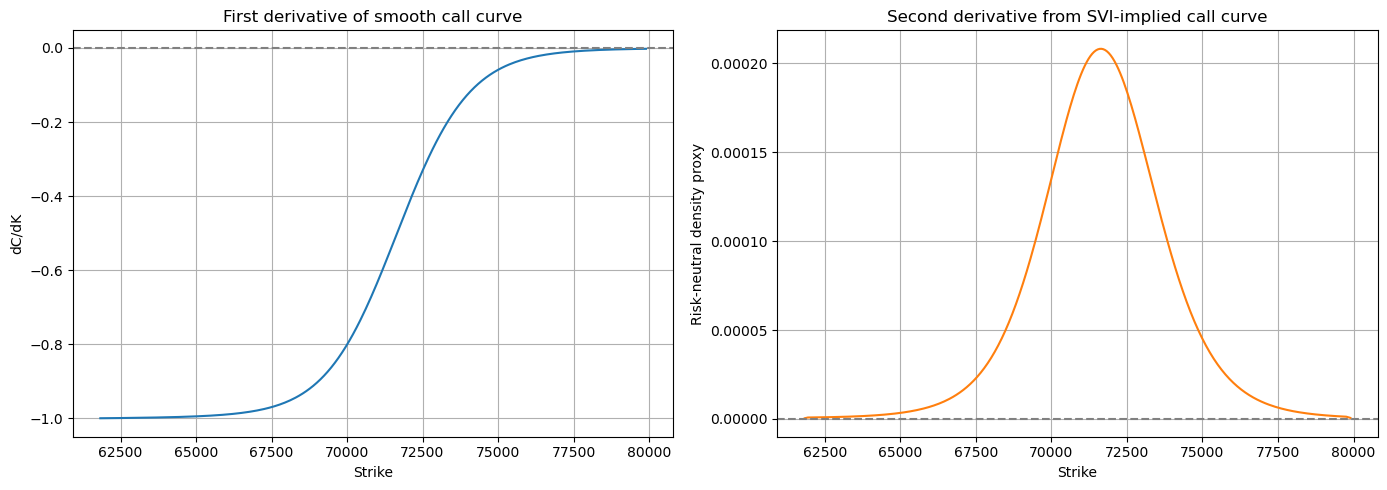

,strike,call_price_svi,dC_dK,tail_q,pdf_q
0,61829.912593,9843.815477,-1.000171,1.000171,4.117449e-07
1,61882.944872,9790.774152,-1.000149,1.000149,6.199327e-07
2,61936.022637,9737.689651,-1.000105,1.000105,8.332355e-07
3,61989.145928,9684.561969,-1.000060,1.000060,8.433756e-07
4,62042.314784,9631.391102,-1.000015,1.000015,8.540513e-07


In [43]:
# Derivamos numericamente sobre la curva suave reconstruida desde SVI.
# Para produccion convendra usar formulas analiticas o AD sobre la parametrizacion.
dC_dK = np.gradient(call_svi_grid, K_grid)
d2C_dK2 = np.gradient(dC_dK, K_grid)
    
tail_q = np.exp(rate * tau) * (-dC_dK)
pdf_q = np.exp(rate * tau) * d2C_dK2

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].plot(K_grid, dC_dK, color="tab:blue")
axes[0].axhline(0.0, linestyle="--", color="gray")
axes[0].set_xlabel("Strike")
axes[0].set_ylabel("dC/dK")
axes[0].set_title("First derivative of smooth call curve")
axes[0].grid(True)

axes[1].plot(K_grid, pdf_q, color="tab:orange")
axes[1].axhline(0.0, linestyle="--", color="gray")
axes[1].set_xlabel("Strike")
axes[1].set_ylabel("Risk-neutral density proxy")
axes[1].set_title("Second derivative from SVI-implied call curve")
axes[1].grid(True)

plt.tight_layout()
plt.show()

df_density = pd.DataFrame({
    "strike": K_grid,
    "call_price_svi": call_svi_grid,
    "dC_dK": dC_dK,
    "tail_q": tail_q,
    "pdf_q": pdf_q,
})

df_density.head()

### **Interval probabilities vs Kalshi**

En este bloque comparamos la probabilidad de rango implicita por Deribit con los precios de Kalshi para cada intervalo `[L, U]`.

La comparacion principal es:

- `q_deribit_range = Q(L <= S_T <= U)`
- `edge_mid = kalshi_yes_mid - q_deribit_range`
- `buy_yes_edge = q_deribit_range - kalshi_yes_ask`
- `sell_yes_edge = kalshi_yes_bid - q_deribit_range`

Por estabilidad numerica usamos la cola `tail_q` interpolada y calculamos:

`Q(L <= S_T <= U) = Q(S_T > L) - Q(S_T > U)`

In [44]:
def _normalize_prob_quote(x):
    if pd.isna(x):
        return np.nan
    x = float(x)
    return x / 100.0 if x > 1.0 else x


def tail_prob_from_strike(strike, density_df=df_density):
    strikes = density_df["strike"].to_numpy(dtype=float)
    tail = np.clip(density_df["tail_q"].to_numpy(dtype=float), 0.0, 1.0)
    return float(np.interp(strike, strikes, tail, left=1.0, right=0.0))


def range_prob_from_tail(lower, upper, density_df=df_density):
    if upper <= lower:
        raise ValueError(f"Invalid interval: lower={lower}, upper={upper}")

    q_lower = tail_prob_from_strike(lower, density_df=density_df)
    q_upper = tail_prob_from_strike(upper, density_df=density_df)
    return float(np.clip(q_lower - q_upper, 0.0, 1.0))


def compare_kalshi_intervals(kalshi_df, density_df=df_density, per_side_fee=0.0):
    required_cols = {"lower", "upper"}
    missing_cols = required_cols - set(kalshi_df.columns)
    if missing_cols:
        raise ValueError(f"kalshi_df is missing columns: {sorted(missing_cols)}")

    result = kalshi_df.copy()

    for col in ["yes_bid", "yes_ask", "yes_mid", "yes_spread", "buy_fee", "sell_fee"]:
        if col in result.columns:
            result[col] = result[col].apply(_normalize_prob_quote)

    if "yes_spread" not in result.columns and {"yes_bid", "yes_ask"}.issubset(result.columns):
        result["yes_spread"] = result["yes_ask"] - result["yes_bid"]

    if "yes_mid" not in result.columns and {"yes_bid", "yes_ask"}.issubset(result.columns):
        result["yes_mid"] = (result["yes_bid"] + result["yes_ask"]) / 2.0

    if "yes_bid" not in result.columns and {"yes_mid", "yes_spread"}.issubset(result.columns):
        result["yes_bid"] = np.clip(result["yes_mid"] - result["yes_spread"] / 2.0, 0.0, 1.0)

    if "yes_ask" not in result.columns and {"yes_mid", "yes_spread"}.issubset(result.columns):
        result["yes_ask"] = np.clip(result["yes_mid"] + result["yes_spread"] / 2.0, 0.0, 1.0)

    if "buy_fee" not in result.columns:
        result["buy_fee"] = float(per_side_fee)

    if "sell_fee" not in result.columns:
        result["sell_fee"] = float(per_side_fee)

    result["q_deribit_range"] = result.apply(
        lambda row: range_prob_from_tail(row["lower"], row["upper"], density_df=density_df),
        axis=1,
    )

    if "yes_mid" in result.columns:
        result["edge_mid"] = result["yes_mid"] - result["q_deribit_range"]

    if "yes_ask" in result.columns:
        result["buy_yes_edge_gross"] = result["q_deribit_range"] - result["yes_ask"]
        result["buy_yes_edge_net"] = result["buy_yes_edge_gross"] - result["buy_fee"]

    if "yes_bid" in result.columns:
        result["sell_yes_edge_gross"] = result["yes_bid"] - result["q_deribit_range"]
        result["sell_yes_edge_net"] = result["sell_yes_edge_gross"] - result["sell_fee"]

    result["trade_signal"] = "NO_TRADE"
    result["signal_edge_net"] = np.nan

    if "buy_yes_edge_net" in result.columns:
        buy_mask = result["buy_yes_edge_net"] > 0
        result.loc[buy_mask, "trade_signal"] = "BUY_YES"
        result.loc[buy_mask, "signal_edge_net"] = result.loc[buy_mask, "buy_yes_edge_net"]

    if "sell_yes_edge_net" in result.columns:
        sell_mask = result["sell_yes_edge_net"] > 0
        better_sell_mask = sell_mask & (
            result["trade_signal"].eq("NO_TRADE")
            | result["sell_yes_edge_net"].gt(result["signal_edge_net"].fillna(-np.inf))
        )
        result.loc[better_sell_mask, "trade_signal"] = "SELL_YES"
        result.loc[better_sell_mask, "signal_edge_net"] = result.loc[better_sell_mask, "sell_yes_edge_net"]

    if "label" not in result.columns:
        result["label"] = result.apply(lambda row: f"[{row['lower']:.2f}, {row['upper']:.2f}]", axis=1)

    result = result.sort_values(["lower", "upper"]).reset_index(drop=True)
    return result


# Ejemplo editable. Puedes pegar aqui los bins y precios que veas en Kalshi.
# Acepta probabilidades en decimales (0.07) o en centavos (7, 8, 12, ...).
# Si solo tienes mid y spread, el codigo infiere bid/ask.
# `per_side_fee` y las columnas `buy_fee` / `sell_fee` se interpretan tambien en formato decimal o centavos.
per_side_fee = 0.0

kalshi_intervals = pd.DataFrame([
    {"label": "$67,800 to $68,299.99", "lower": 67800.00, "upper": 68299.99, "yes_mid": 8, "yes_spread": 2},
    {"label": "$68,300 to $68,799.99", "lower": 68300.00, "upper": 68799.99, "yes_mid": 7, "yes_spread": 2},
    {"label": "$68,800 to $69,299.99", "lower": 68800.00, "upper": 69299.99, "yes_mid": 6, "yes_spread": 2},
])

comparison_df = compare_kalshi_intervals(kalshi_intervals, per_side_fee=per_side_fee)
comparison_df

,label,lower,upper,yes_mid,yes_spread,yes_bid,yes_ask,buy_fee,sell_fee,q_deribit_range,edge_mid,buy_yes_edge_gross,buy_yes_edge_net,sell_yes_edge_gross,sell_yes_edge_net,trade_signal,signal_edge_net
0,"$67,800 to $68,299.99",67800.0,68299.99,0.08,0.02,0.07,0.09,0.0,0.0,0.017955,0.062045,-0.072045,-0.072045,0.052045,0.052045,SELL_YES,0.052045
1,"$68,300 to $68,799.99",68300.0,68799.99,0.07,0.02,0.06,0.08,0.0,0.0,0.026502,0.043498,-0.053498,-0.053498,0.033498,0.033498,SELL_YES,0.033498
2,"$68,800 to $69,299.99",68800.0,69299.99,0.06,0.02,0.05,0.07,0.0,0.0,0.038086,0.021914,-0.031914,-0.031914,0.011914,0.011914,SELL_YES,0.011914


### **Kalshi API auto-load**

Estas celdas descargan mercados de Kalshi automaticamente usando la API publica de market data.

Flujo:

1. buscar mercados BTC range,
2. elegir el evento mas cercano a la expiry objetivo,
3. normalizar precios ejecutables y metricas,
4. construir `comparison_df` directamente desde Kalshi.

Si conoces el `event_ticker`, ponlo explicitamente para evitar ambiguedad.

In [45]:
import re
import requests

KALSHI_BASE_URL = "https://api.elections.kalshi.com/trade-api/v2"


def _kalshi_to_float(x):
    if pd.isna(x):
        return np.nan
    if isinstance(x, (int, float, np.integer, np.floating)):
        return float(x)
    x = str(x).strip().replace(",", "")
    if not x:
        return np.nan
    try:
        return float(x)
    except ValueError:
        return np.nan


def _first_existing(row, cols):
    for col in cols:
        if col in row.index and pd.notna(row[col]):
            return row[col]
    return np.nan


def kalshi_get(path, params=None, timeout=15):
    response = requests.get(f"{KALSHI_BASE_URL}{path}", params=params, timeout=timeout)
    response.raise_for_status()
    return response.json()


def kalshi_get_all_markets(params=None, timeout=15):
    params = dict(params or {})
    params.setdefault("limit", 1000)
    markets = []
    cursor = None

    while True:
        request_params = dict(params)
        if cursor:
            request_params["cursor"] = cursor

        payload = kalshi_get("/markets", params=request_params, timeout=timeout)
        markets.extend(payload.get("markets", []))
        cursor = payload.get("cursor")
        if not cursor:
            break

    return markets


def kalshi_choose_event(markets_df, target_dt=None):
    if markets_df.empty:
        raise ValueError("No Kalshi markets available after filtering.")

    event_summary = (
        markets_df.groupby("event_ticker", dropna=False)
        .agg(
            close_time=("close_time", "min"),
            expected_expiration_time=("expected_expiration_time", "min"),
            market_count=("ticker", "count"),
            title=("title", "first"),
        )
        .reset_index()
    )

    reference_ts = pd.Timestamp(target_dt) if target_dt is not None else pd.Timestamp.now(tz="UTC")
    if reference_ts.tzinfo is None:
        reference_ts = reference_ts.tz_localize("UTC")

    event_summary["reference_time"] = event_summary["close_time"].fillna(event_summary["expected_expiration_time"])
    event_summary["time_distance_seconds"] = (
        event_summary["reference_time"] - reference_ts
    ).abs().dt.total_seconds()
    event_summary = event_summary.sort_values(["time_distance_seconds", "event_ticker"]).reset_index(drop=True)
    return event_summary.iloc[0]["event_ticker"], event_summary


def kalshi_extract_bounds(row):
    lower = _kalshi_to_float(_first_existing(row, ["floor_strike", "floor_strike_dollars", "strike_floor"]))
    upper = _kalshi_to_float(_first_existing(row, ["cap_strike", "cap_strike_dollars", "strike_cap"]))

    if pd.notna(lower) and pd.notna(upper):
        return lower, upper

    text_candidates = [
        _first_existing(row, ["subtitle"]),
        _first_existing(row, ["yes_sub_title"]),
        _first_existing(row, ["title"]),
        _first_existing(row, ["functional_strike"]),
    ]
    pattern = re.compile(r"\$?\s*([\d,]+(?:\.\d+)?)\s*(?:to|-|–|—)\s*\$?\s*([\d,]+(?:\.\d+)?)", re.IGNORECASE)

    for candidate in text_candidates:
        if pd.isna(candidate):
            continue
        match = pattern.search(str(candidate))
        if match:
            lower = float(match.group(1).replace(",", ""))
            upper = float(match.group(2).replace(",", ""))
            return lower, upper

    return np.nan, np.nan


def kalshi_normalize_range_markets(markets_df):
    df = markets_df.copy()
    if df.empty:
        return df

    for time_col in ["close_time", "expiration_time", "expected_expiration_time", "latest_expiration_time", "updated_time"]:
        if time_col in df.columns:
            df[time_col] = pd.to_datetime(df[time_col], utc=True, errors="coerce")

    bounds = df.apply(kalshi_extract_bounds, axis=1, result_type="expand")
    bounds.columns = ["lower", "upper"]
    df = pd.concat([df, bounds], axis=1)
    df = df[df["lower"].notna() & df["upper"].notna()].copy()

    numeric_cols = {
        "yes_bid": ["yes_bid_dollars", "yes_bid"],
        "yes_ask": ["yes_ask_dollars", "yes_ask"],
        "yes_mid": ["last_price_dollars", "last_price"],
        "yes_bid_size": ["yes_bid_size_fp", "yes_bid_size"],
        "yes_ask_size": ["yes_ask_size_fp", "yes_ask_size"],
        "volume": ["volume_fp", "volume"],
        "volume_24h": ["volume_24h_fp", "volume_24h"],
        "open_interest": ["open_interest_fp", "open_interest"],
        "liquidity": ["liquidity_dollars", "liquidity"],
        "tick_size": ["tick_size"],
    }

    for new_col, candidates in numeric_cols.items():
        source_col = next((col for col in candidates if col in df.columns), None)
        if source_col is not None:
            df[new_col] = df[source_col].apply(_kalshi_to_float)
        else:
            df[new_col] = np.nan

    if df["yes_mid"].isna().all() and {"yes_bid", "yes_ask"}.issubset(df.columns):
        df["yes_mid"] = (df["yes_bid"] + df["yes_ask"]) / 2.0

    df["yes_spread"] = df["yes_ask"] - df["yes_bid"]
    df["label"] = df.apply(
        lambda row: row["subtitle"] if "subtitle" in row.index and pd.notna(row["subtitle"]) else f"[{row['lower']:.2f}, {row['upper']:.2f}]",
        axis=1,
    )

    keep_cols = [
        "ticker",
        "event_ticker",
        "status",
        "title",
        "subtitle",
        "yes_sub_title",
        "label",
        "lower",
        "upper",
        "yes_bid",
        "yes_ask",
        "yes_mid",
        "yes_spread",
        "yes_bid_size",
        "yes_ask_size",
        "volume",
        "volume_24h",
        "open_interest",
        "liquidity",
        "tick_size",
        "close_time",
        "expiration_time",
        "expected_expiration_time",
        "latest_expiration_time",
        "updated_time",
    ]
    keep_cols = [col for col in keep_cols if col in df.columns]
    return df[keep_cols].sort_values(["lower", "upper"]).reset_index(drop=True)


def load_kalshi_btc_range_markets(
    event_ticker=None,
    series_ticker="KXBTC",
    title_contains="Bitcoin price range",
    status="open",
    target_dt=None,
):
    params = {"limit": 1000, "mve_filter": "exclude"}
    if series_ticker:
        params["series_ticker"] = series_ticker
    if status:
        params["status"] = status
    if event_ticker:
        params["event_ticker"] = event_ticker

    markets = kalshi_get_all_markets(params=params)
    raw_df = pd.DataFrame(markets)
    if raw_df.empty:
        raise ValueError("Kalshi API returned no markets for the requested filters.")

    for time_col in ["close_time", "expiration_time", "expected_expiration_time", "latest_expiration_time", "updated_time"]:
        if time_col in raw_df.columns:
            raw_df[time_col] = pd.to_datetime(raw_df[time_col], utc=True, errors="coerce")

    if title_contains:
        text_cols = [col for col in ["title", "subtitle", "yes_sub_title"] if col in raw_df.columns]
        text_block = raw_df[text_cols].fillna("").agg(" ".join, axis=1) if text_cols else pd.Series("", index=raw_df.index)
        raw_df = raw_df[text_block.str.contains(title_contains, case=False, regex=False)].copy()

    if raw_df.empty:
        raise ValueError("No Kalshi markets left after title filtering. Try changing `title_contains` or set `event_ticker` explicitly.")

    if not event_ticker:
        selected_event_ticker, event_candidates_df = kalshi_choose_event(raw_df, target_dt=target_dt)
        raw_df = raw_df[raw_df["event_ticker"] == selected_event_ticker].copy()
    else:
        selected_event_ticker = event_ticker
        event_candidates_df = pd.DataFrame()

    normalized_df = kalshi_normalize_range_markets(raw_df)
    if normalized_df.empty:
        raise ValueError("Kalshi markets were found, but interval bounds could not be extracted.")

    return normalized_df, event_candidates_df, selected_event_ticker


In [46]:
# Configuracion Kalshi.
# Si conoces el event_ticker exacto, ponlo aqui para evitar ambiguedad.
kalshi_event_ticker = None
kalshi_series_ticker = "KXBTC"
kalshi_title_contains = "Bitcoin price range"
kalshi_status = "open"
kalshi_target_dt = expiry_dt if "expiry_dt" in globals() else None

kalshi_api_df, kalshi_event_candidates_df, kalshi_selected_event_ticker = load_kalshi_btc_range_markets(
    event_ticker=kalshi_event_ticker,
    series_ticker=kalshi_series_ticker,
    title_contains=kalshi_title_contains,
    status=kalshi_status,
    target_dt=kalshi_target_dt,
)

print(f"selected Kalshi event_ticker = {kalshi_selected_event_ticker}")
if not kalshi_event_candidates_df.empty:
    display(kalshi_event_candidates_df.head(10))

display(kalshi_api_df)

comparison_df = compare_kalshi_intervals(kalshi_api_df, per_side_fee=per_side_fee)
comparison_df

selected Kalshi event_ticker = KXBTC-26APR1017


,event_ticker,close_time,expected_expiration_time,market_count,title,reference_time,time_distance_seconds
0,KXBTC-26APR1017,2026-04-10 21:00:00+00:00,2026-04-10 21:05:00+00:00,50,"Bitcoin price range on Apr 10, 2026?",2026-04-10 21:00:00+00:00,46800.0
1,KXBTC-26APR0817,2026-04-08 21:00:00+00:00,2026-04-08 21:05:00+00:00,80,"Bitcoin price range on Apr 8, 2026?",2026-04-08 21:00:00+00:00,126000.0
2,KXBTC-26APR0806,2026-04-08 10:00:00+00:00,2026-04-08 10:05:00+00:00,188,"Bitcoin price range on Apr 8, 2026?",2026-04-08 10:00:00+00:00,165600.0


,ticker,event_ticker,status,title,subtitle,yes_sub_title,label,lower,upper,yes_bid,...,volume,volume_24h,open_interest,liquidity,tick_size,close_time,expiration_time,expected_expiration_time,latest_expiration_time,updated_time
0,KXBTC-26APR1017-B54750,KXBTC-26APR1017,active,"Bitcoin price range on Apr 10, 2026?","$54,500 to 54,999.99","$54,500 to 54,999.99","$54,500 to 54,999.99",54500.0,54999.99,0.00,...,0.0,0.0,0.0,0.0,1.0,2026-04-10 21:00:00+00:00,2026-04-17 21:00:00+00:00,2026-04-10 21:05:00+00:00,2026-04-17 21:00:00+00:00,2026-04-03 20:00:01.143229+00:00
1,KXBTC-26APR1017-B55250,KXBTC-26APR1017,active,"Bitcoin price range on Apr 10, 2026?","$55,000 to 55,499.99","$55,000 to 55,499.99","$55,000 to 55,499.99",55000.0,55499.99,0.00,...,0.0,0.0,0.0,0.0,1.0,2026-04-10 21:00:00+00:00,2026-04-17 21:00:00+00:00,2026-04-10 21:05:00+00:00,2026-04-17 21:00:00+00:00,2026-04-03 20:00:01.143229+00:00
2,KXBTC-26APR1017-B55750,KXBTC-26APR1017,active,"Bitcoin price range on Apr 10, 2026?","$55,500 to 55,999.99","$55,500 to 55,999.99","$55,500 to 55,999.99",55500.0,55999.99,0.00,...,0.0,0.0,0.0,0.0,1.0,2026-04-10 21:00:00+00:00,2026-04-17 21:00:00+00:00,2026-04-10 21:05:00+00:00,2026-04-17 21:00:00+00:00,2026-04-03 20:00:01.143229+00:00
3,KXBTC-26APR1017-B56250,KXBTC-26APR1017,active,"Bitcoin price range on Apr 10, 2026?","$56,000 to 56,499.99","$56,000 to 56,499.99","$56,000 to 56,499.99",56000.0,56499.99,0.00,...,287.0,0.0,287.0,0.0,1.0,2026-04-10 21:00:00+00:00,2026-04-17 21:00:00+00:00,2026-04-10 21:05:00+00:00,2026-04-17 21:00:00+00:00,2026-04-03 20:00:01.143229+00:00
4,KXBTC-26APR1017-B56750,KXBTC-26APR1017,active,"Bitcoin price range on Apr 10, 2026?","$56,500 to 56,999.99","$56,500 to 56,999.99","$56,500 to 56,999.99",56500.0,56999.99,0.00,...,0.0,0.0,0.0,0.0,1.0,2026-04-10 21:00:00+00:00,2026-04-17 21:00:00+00:00,2026-04-10 21:05:00+00:00,2026-04-17 21:00:00+00:00,2026-04-03 20:00:01.143229+00:00
5,KXBTC-26APR1017-B57250,KXBTC-26APR1017,active,"Bitcoin price range on Apr 10, 2026?","$57,000 to 57,499.99","$57,000 to 57,499.99","$57,000 to 57,499.99",57000.0,57499.99,0.00,...,0.0,0.0,0.0,0.0,1.0,2026-04-10 21:00:00+00:00,2026-04-17 21:00:00+00:00,2026-04-10 21:05:00+00:00,2026-04-17 21:00:00+00:00,2026-04-03 20:00:01.143229+00:00
6,KXBTC-26APR1017-B57750,KXBTC-26APR1017,active,"Bitcoin price range on Apr 10, 2026?","$57,500 to 57,999.99","$57,500 to 57,999.99","$57,500 to 57,999.99",57500.0,57999.99,0.00,...,500.0,0.0,500.0,0.0,1.0,2026-04-10 21:00:00+00:00,2026-04-17 21:00:00+00:00,2026-04-10 21:05:00+00:00,2026-04-17 21:00:00+00:00,2026-04-03 20:00:01.143229+00:00
7,KXBTC-26APR1017-B58250,KXBTC-26APR1017,active,"Bitcoin price range on Apr 10, 2026?","$58,000 to 58,499.99","$58,000 to 58,499.99","$58,000 to 58,499.99",58000.0,58499.99,0.00,...,0.0,0.0,0.0,0.0,1.0,2026-04-10 21:00:00+00:00,2026-04-17 21:00:00+00:00,2026-04-10 21:05:00+00:00,2026-04-17 21:00:00+00:00,2026-04-03 20:00:01.143229+00:00
8,KXBTC-26APR1017-B58750,KXBTC-26APR1017,active,"Bitcoin price range on Apr 10, 2026?","$58,500 to 58,999.99","$58,500 to 58,999.99","$58,500 to 58,999.99",58500.0,58999.99,0.00,...,0.0,0.0,0.0,0.0,1.0,2026-04-10 21:00:00+00:00,2026-04-17 21:00:00+00:00,2026-04-10 21:05:00+00:00,2026-04-17 21:00:00+00:00,2026-04-03 20:00:01.143229+00:00
9,KXBTC-26APR1017-B59250,KXBTC-26APR1017,active,"Bitcoin price range on Apr 10, 2026?","$59,000 to 59,499.99","$59,000 to 59,499.99","$59,000 to 59,499.99",59000.0,59499.99,0.00,...,124.0,0.0,124.0,0.0,1.0,2026-04-10 21:00:00+00:00,2026-04-17 21:00:00+00:00,2026-04-10 21:05:00+00:00,2026-04-17 21:00:00+00:00,2026-04-03 20:00:01.143229+00:00


,ticker,event_ticker,status,title,subtitle,yes_sub_title,label,lower,upper,yes_bid,...,buy_fee,sell_fee,q_deribit_range,edge_mid,buy_yes_edge_gross,buy_yes_edge_net,sell_yes_edge_gross,sell_yes_edge_net,trade_signal,signal_edge_net
0,KXBTC-26APR1017-B54750,KXBTC-26APR1017,active,"Bitcoin price range on Apr 10, 2026?","$54,500 to 54,999.99","$54,500 to 54,999.99","$54,500 to 54,999.99",54500.0,54999.99,0.00,...,0.0,0.0,0.000000,0.000000,-0.010000,-0.010000,0.000000,0.000000,NO_TRADE,NaN
1,KXBTC-26APR1017-B55250,KXBTC-26APR1017,active,"Bitcoin price range on Apr 10, 2026?","$55,000 to 55,499.99","$55,000 to 55,499.99","$55,000 to 55,499.99",55000.0,55499.99,0.00,...,0.0,0.0,0.000000,0.000000,-0.010000,-0.010000,0.000000,0.000000,NO_TRADE,NaN
2,KXBTC-26APR1017-B55750,KXBTC-26APR1017,active,"Bitcoin price range on Apr 10, 2026?","$55,500 to 55,999.99","$55,500 to 55,999.99","$55,500 to 55,999.99",55500.0,55999.99,0.00,...,0.0,0.0,0.000000,0.000000,-0.010000,-0.010000,0.000000,0.000000,NO_TRADE,NaN
3,KXBTC-26APR1017-B56250,KXBTC-26APR1017,active,"Bitcoin price range on Apr 10, 2026?","$56,000 to 56,499.99","$56,000 to 56,499.99","$56,000 to 56,499.99",56000.0,56499.99,0.00,...,0.0,0.0,0.000000,0.010000,-0.010000,-0.010000,0.000000,0.000000,NO_TRADE,NaN
4,KXBTC-26APR1017-B56750,KXBTC-26APR1017,active,"Bitcoin price range on Apr 10, 2026?","$56,500 to 56,999.99","$56,500 to 56,999.99","$56,500 to 56,999.99",56500.0,56999.99,0.00,...,0.0,0.0,0.000000,0.000000,-0.010000,-0.010000,0.000000,0.000000,NO_TRADE,NaN
5,KXBTC-26APR1017-B57250,KXBTC-26APR1017,active,"Bitcoin price range on Apr 10, 2026?","$57,000 to 57,499.99","$57,000 to 57,499.99","$57,000 to 57,499.99",57000.0,57499.99,0.00,...,0.0,0.0,0.000000,0.000000,-0.010000,-0.010000,0.000000,0.000000,NO_TRADE,NaN
6,KXBTC-26APR1017-B57750,KXBTC-26APR1017,active,"Bitcoin price range on Apr 10, 2026?","$57,500 to 57,999.99","$57,500 to 57,999.99","$57,500 to 57,999.99",57500.0,57999.99,0.00,...,0.0,0.0,0.000000,0.020000,-0.010000,-0.010000,0.000000,0.000000,NO_TRADE,NaN
7,KXBTC-26APR1017-B58250,KXBTC-26APR1017,active,"Bitcoin price range on Apr 10, 2026?","$58,000 to 58,499.99","$58,000 to 58,499.99","$58,000 to 58,499.99",58000.0,58499.99,0.00,...,0.0,0.0,0.000000,0.000000,-0.010000,-0.010000,0.000000,0.000000,NO_TRADE,NaN
8,KXBTC-26APR1017-B58750,KXBTC-26APR1017,active,"Bitcoin price range on Apr 10, 2026?","$58,500 to 58,999.99","$58,500 to 58,999.99","$58,500 to 58,999.99",58500.0,58999.99,0.00,...,0.0,0.0,0.000000,0.000000,-0.010000,-0.010000,0.000000,0.000000,NO_TRADE,NaN
9,KXBTC-26APR1017-B59250,KXBTC-26APR1017,active,"Bitcoin price range on Apr 10, 2026?","$59,000 to 59,499.99","$59,000 to 59,499.99","$59,000 to 59,499.99",59000.0,59499.99,0.00,...,0.0,0.0,0.000000,0.020000,-0.010000,-0.010000,0.000000,0.000000,NO_TRADE,NaN


### **Kalshi strip validation and cleanup**

Este bloque revisa si el strip de Kalshi parece una particion razonable del evento:

- un solo `event_ticker`,
- sin intervalos duplicados,
- sin solapes,
- con huecos visibles entre bins,
- y con suma de probabilidades cercana a 1 cuando corresponde.

Tambien crea un `kalshi_clean_df` deduplicado para usarlo en la comparacion.

In [47]:
def validate_kalshi_strip(kalshi_df, prob_col="yes_mid", gap_tolerance=1.0):
    if kalshi_df.empty:
        raise ValueError("kalshi_df is empty")

    df = kalshi_df.copy().sort_values(["lower", "upper"]).reset_index(drop=True)
    duplicate_mask = df.duplicated(subset=["lower", "upper"], keep=False)
    duplicates_df = df.loc[duplicate_mask].copy()
    clean_df = df.drop_duplicates(subset=["lower", "upper"], keep="first").copy().reset_index(drop=True)

    overlaps = []
    gaps = []
    adjacency = []

    for idx in range(len(clean_df) - 1):
        current = clean_df.iloc[idx]
        nxt = clean_df.iloc[idx + 1]
        delta = float(nxt["lower"] - current["upper"])
        adjacency.append({
            "left_label": current.get("label", current.get("ticker", idx)),
            "right_label": nxt.get("label", nxt.get("ticker", idx + 1)),
            "left_upper": current["upper"],
            "right_lower": nxt["lower"],
            "delta": delta,
        })

        if delta < -gap_tolerance:
            overlaps.append({
                "left_label": current.get("label", current.get("ticker", idx)),
                "right_label": nxt.get("label", nxt.get("ticker", idx + 1)),
                "left_upper": current["upper"],
                "right_lower": nxt["lower"],
                "overlap_size": -delta,
            })
        elif delta > gap_tolerance:
            gaps.append({
                "left_label": current.get("label", current.get("ticker", idx)),
                "right_label": nxt.get("label", nxt.get("ticker", idx + 1)),
                "left_upper": current["upper"],
                "right_lower": nxt["lower"],
                "gap_size": delta,
            })

    summary = pd.DataFrame([
        {"metric": "num_rows_raw", "value": len(df)},
        {"metric": "num_rows_clean", "value": len(clean_df)},
        {"metric": "unique_event_tickers", "value": clean_df["event_ticker"].nunique() if "event_ticker" in clean_df.columns else np.nan},
        {"metric": "num_duplicate_intervals", "value": len(duplicates_df)},
        {"metric": "num_overlaps", "value": len(overlaps)},
        {"metric": "num_gaps", "value": len(gaps)},
        {"metric": f"sum_{prob_col}", "value": clean_df[prob_col].sum() if prob_col in clean_df.columns else np.nan},
        {"metric": f"abs_1_minus_sum_{prob_col}", "value": abs(1.0 - clean_df[prob_col].sum()) if prob_col in clean_df.columns else np.nan},
        {"metric": "min_lower", "value": clean_df["lower"].min()},
        {"metric": "max_upper", "value": clean_df["upper"].max()},
    ])

    return {
        "clean_df": clean_df,
        "summary_df": summary,
        "duplicates_df": duplicates_df,
        "overlaps_df": pd.DataFrame(overlaps),
        "gaps_df": pd.DataFrame(gaps),
        "adjacency_df": pd.DataFrame(adjacency),
    }


kalshi_strip_check = validate_kalshi_strip(kalshi_api_df, prob_col="yes_mid", gap_tolerance=1.0)
kalshi_clean_df = kalshi_strip_check["clean_df"]
kalshi_strip_summary_df = kalshi_strip_check["summary_df"]
kalshi_duplicates_df = kalshi_strip_check["duplicates_df"]
kalshi_overlaps_df = kalshi_strip_check["overlaps_df"]
kalshi_gaps_df = kalshi_strip_check["gaps_df"]
kalshi_adjacency_df = kalshi_strip_check["adjacency_df"]

display(kalshi_strip_summary_df)

if not kalshi_duplicates_df.empty:
    print("Duplicate intervals detected:")
    display(kalshi_duplicates_df)

if not kalshi_overlaps_df.empty:
    print("Overlapping intervals detected:")
    display(kalshi_overlaps_df)

if not kalshi_gaps_df.empty:
    print("Gaps detected between intervals:")
    display(kalshi_gaps_df)

comparison_df = compare_kalshi_intervals(kalshi_clean_df, per_side_fee=per_side_fee)
comparison_df

,metric,value
0,num_rows_raw,48.00
1,num_rows_clean,48.00
2,unique_event_tickers,1.00
3,num_duplicate_intervals,0.00
4,num_overlaps,0.00
5,num_gaps,0.00
6,sum_yes_mid,1.44
7,abs_1_minus_sum_yes_mid,0.44
8,min_lower,54500.00
9,max_upper,78499.99


,ticker,event_ticker,status,title,subtitle,yes_sub_title,label,lower,upper,yes_bid,...,buy_fee,sell_fee,q_deribit_range,edge_mid,buy_yes_edge_gross,buy_yes_edge_net,sell_yes_edge_gross,sell_yes_edge_net,trade_signal,signal_edge_net
0,KXBTC-26APR1017-B54750,KXBTC-26APR1017,active,"Bitcoin price range on Apr 10, 2026?","$54,500 to 54,999.99","$54,500 to 54,999.99","$54,500 to 54,999.99",54500.0,54999.99,0.00,...,0.0,0.0,0.000000,0.000000,-0.010000,-0.010000,0.000000,0.000000,NO_TRADE,NaN
1,KXBTC-26APR1017-B55250,KXBTC-26APR1017,active,"Bitcoin price range on Apr 10, 2026?","$55,000 to 55,499.99","$55,000 to 55,499.99","$55,000 to 55,499.99",55000.0,55499.99,0.00,...,0.0,0.0,0.000000,0.000000,-0.010000,-0.010000,0.000000,0.000000,NO_TRADE,NaN
2,KXBTC-26APR1017-B55750,KXBTC-26APR1017,active,"Bitcoin price range on Apr 10, 2026?","$55,500 to 55,999.99","$55,500 to 55,999.99","$55,500 to 55,999.99",55500.0,55999.99,0.00,...,0.0,0.0,0.000000,0.000000,-0.010000,-0.010000,0.000000,0.000000,NO_TRADE,NaN
3,KXBTC-26APR1017-B56250,KXBTC-26APR1017,active,"Bitcoin price range on Apr 10, 2026?","$56,000 to 56,499.99","$56,000 to 56,499.99","$56,000 to 56,499.99",56000.0,56499.99,0.00,...,0.0,0.0,0.000000,0.010000,-0.010000,-0.010000,0.000000,0.000000,NO_TRADE,NaN
4,KXBTC-26APR1017-B56750,KXBTC-26APR1017,active,"Bitcoin price range on Apr 10, 2026?","$56,500 to 56,999.99","$56,500 to 56,999.99","$56,500 to 56,999.99",56500.0,56999.99,0.00,...,0.0,0.0,0.000000,0.000000,-0.010000,-0.010000,0.000000,0.000000,NO_TRADE,NaN
5,KXBTC-26APR1017-B57250,KXBTC-26APR1017,active,"Bitcoin price range on Apr 10, 2026?","$57,000 to 57,499.99","$57,000 to 57,499.99","$57,000 to 57,499.99",57000.0,57499.99,0.00,...,0.0,0.0,0.000000,0.000000,-0.010000,-0.010000,0.000000,0.000000,NO_TRADE,NaN
6,KXBTC-26APR1017-B57750,KXBTC-26APR1017,active,"Bitcoin price range on Apr 10, 2026?","$57,500 to 57,999.99","$57,500 to 57,999.99","$57,500 to 57,999.99",57500.0,57999.99,0.00,...,0.0,0.0,0.000000,0.020000,-0.010000,-0.010000,0.000000,0.000000,NO_TRADE,NaN
7,KXBTC-26APR1017-B58250,KXBTC-26APR1017,active,"Bitcoin price range on Apr 10, 2026?","$58,000 to 58,499.99","$58,000 to 58,499.99","$58,000 to 58,499.99",58000.0,58499.99,0.00,...,0.0,0.0,0.000000,0.000000,-0.010000,-0.010000,0.000000,0.000000,NO_TRADE,NaN
8,KXBTC-26APR1017-B58750,KXBTC-26APR1017,active,"Bitcoin price range on Apr 10, 2026?","$58,500 to 58,999.99","$58,500 to 58,999.99","$58,500 to 58,999.99",58500.0,58999.99,0.00,...,0.0,0.0,0.000000,0.000000,-0.010000,-0.010000,0.000000,0.000000,NO_TRADE,NaN
9,KXBTC-26APR1017-B59250,KXBTC-26APR1017,active,"Bitcoin price range on Apr 10, 2026?","$59,000 to 59,499.99","$59,000 to 59,499.99","$59,000 to 59,499.99",59000.0,59499.99,0.00,...,0.0,0.0,0.000000,0.020000,-0.010000,-0.010000,0.000000,0.000000,NO_TRADE,NaN


### **Tradable opportunities filter**

Este bloque filtra `comparison_df` para quedarnos solo con oportunidades potencialmente tradables.

Ideas tipicas:

- exigir edge neto minimo,
- exigir spread maximo,
- exigir liquidez minima,
- descartar bins fuera del rango de strikes donde la estimacion Deribit es menos fiable.

In [48]:
def filter_tradable_opportunities(
    comparison_df,
    side="buy_yes",
    min_net_edge=0.0,
    max_spread=None,
    min_bid_size=None,
    min_ask_size=None,
    min_volume=None,
    min_open_interest=None,
    require_inside_density_grid=True,
    density_df=df_density,
):
    result = comparison_df.copy()

    if side not in {"buy_yes", "sell_yes"}:
        raise ValueError("side must be 'buy_yes' or 'sell_yes'")

    edge_col = "buy_yes_edge_net" if side == "buy_yes" else "sell_yes_edge_net"
    if edge_col not in result.columns:
        raise ValueError(f"{edge_col} not found in comparison_df")

    mask = result[edge_col] >= float(min_net_edge)

    if max_spread is not None and "yes_spread" in result.columns:
        max_spread = _normalize_prob_quote(max_spread)
        mask &= result["yes_spread"].notna() & (result["yes_spread"] <= max_spread)

    if min_bid_size is not None and "yes_bid_size" in result.columns:
        mask &= result["yes_bid_size"].notna() & (result["yes_bid_size"] >= float(min_bid_size))

    if min_ask_size is not None and "yes_ask_size" in result.columns:
        mask &= result["yes_ask_size"].notna() & (result["yes_ask_size"] >= float(min_ask_size))

    if min_volume is not None and "volume" in result.columns:
        mask &= result["volume"].notna() & (result["volume"] >= float(min_volume))

    if min_open_interest is not None and "open_interest" in result.columns:
        mask &= result["open_interest"].notna() & (result["open_interest"] >= float(min_open_interest))

    if require_inside_density_grid:
        strike_min = float(density_df["strike"].min())
        strike_max = float(density_df["strike"].max())
        mask &= (result["lower"] >= strike_min) & (result["upper"] <= strike_max)

    filtered = result.loc[mask].copy()
    filtered = filtered.sort_values(edge_col, ascending=False).reset_index(drop=True)
    return filtered


# Configuracion de filtro.
# Puedes usar decimales (0.01) o centavos (1) en `min_net_edge` y `max_spread`.
opportunity_side = "buy_yes"
min_net_edge = 0.0
max_spread = 3
min_bid_size = None
min_ask_size = None
min_volume = None
min_open_interest = None
require_inside_density_grid = True

tradable_df = filter_tradable_opportunities(
    comparison_df,
    side=opportunity_side,
    min_net_edge=_normalize_prob_quote(min_net_edge),
    max_spread=max_spread,
    min_bid_size=min_bid_size,
    min_ask_size=min_ask_size,
    min_volume=min_volume,
    min_open_interest=min_open_interest,
    require_inside_density_grid=require_inside_density_grid,
)

tradable_df

,ticker,event_ticker,status,title,subtitle,yes_sub_title,label,lower,upper,yes_bid,...,buy_fee,sell_fee,q_deribit_range,edge_mid,buy_yes_edge_gross,buy_yes_edge_net,sell_yes_edge_gross,sell_yes_edge_net,trade_signal,signal_edge_net
0,KXBTC-26APR1017-B70750,KXBTC-26APR1017,active,"Bitcoin price range on Apr 10, 2026?","$70,500 to 70,999.99","$70,500 to 70,999.99","$70,500 to 70,999.99",70500.0,70999.99,0.06,...,0.0,0.0,0.091271,-0.021271,0.021271,0.021271,-0.031271,-0.031271,BUY_YES,0.021271
1,KXBTC-26APR1017-B71250,KXBTC-26APR1017,active,"Bitcoin price range on Apr 10, 2026?","$71,000 to 71,499.99","$71,000 to 71,499.99","$71,000 to 71,499.99",71000.0,71499.99,0.06,...,0.0,0.0,0.101262,-0.021262,0.021262,0.021262,-0.041262,-0.041262,BUY_YES,0.021262
2,KXBTC-26APR1017-B71750,KXBTC-26APR1017,active,"Bitcoin price range on Apr 10, 2026?","$71,500 to 71,999.99","$71,500 to 71,999.99","$71,500 to 71,999.99",71500.0,71999.99,0.07,...,0.0,0.0,0.103518,-0.013518,0.013518,0.013518,-0.033518,-0.033518,BUY_YES,0.013518
3,KXBTC-26APR1017-B72250,KXBTC-26APR1017,active,"Bitcoin price range on Apr 10, 2026?","$72,000 to 72,499.99","$72,000 to 72,499.99","$72,000 to 72,499.99",72000.0,72499.99,0.07,...,0.0,0.0,0.097482,-0.007482,0.007482,0.007482,-0.027482,-0.027482,BUY_YES,0.007482
4,KXBTC-26APR1017-B69250,KXBTC-26APR1017,active,"Bitcoin price range on Apr 10, 2026?","$69,000 to 69,499.99","$69,000 to 69,499.99","$69,000 to 69,499.99",69000.0,69499.99,0.03,...,0.0,0.0,0.043659,0.006341,0.003659,0.003659,-0.013659,-0.013659,BUY_YES,0.003659


In [49]:
summary_rows = [
    {"metric": "sum_q_deribit_range", "value": comparison_df["q_deribit_range"].sum()},
    {"metric": "sum_kalshi_yes_mid", "value": comparison_df["yes_mid"].sum() if "yes_mid" in comparison_df.columns else np.nan},
    {"metric": "sum_kalshi_yes_bid", "value": comparison_df["yes_bid"].sum() if "yes_bid" in comparison_df.columns else np.nan},
    {"metric": "sum_kalshi_yes_ask", "value": comparison_df["yes_ask"].sum() if "yes_ask" in comparison_df.columns else np.nan},
    {"metric": "basket_edge_mid", "value": comparison_df["q_deribit_range"].sum() - comparison_df["yes_mid"].sum() if "yes_mid" in comparison_df.columns else np.nan},
    {"metric": "basket_buy_yes_edge_gross", "value": comparison_df["buy_yes_edge_gross"].sum() if "buy_yes_edge_gross" in comparison_df.columns else np.nan},
    {"metric": "basket_buy_yes_edge_net", "value": comparison_df["buy_yes_edge_net"].sum() if "buy_yes_edge_net" in comparison_df.columns else np.nan},
    {"metric": "basket_sell_yes_edge_gross", "value": comparison_df["sell_yes_edge_gross"].sum() if "sell_yes_edge_gross" in comparison_df.columns else np.nan},
    {"metric": "basket_sell_yes_edge_net", "value": comparison_df["sell_yes_edge_net"].sum() if "sell_yes_edge_net" in comparison_df.columns else np.nan},
    {"metric": "sum_buy_fees", "value": comparison_df["buy_fee"].sum() if "buy_fee" in comparison_df.columns else np.nan},
    {"metric": "sum_sell_fees", "value": comparison_df["sell_fee"].sum() if "sell_fee" in comparison_df.columns else np.nan},
    {"metric": "num_intervals", "value": len(comparison_df)},
    {"metric": "min_strike_grid", "value": df_density["strike"].min()},
    {"metric": "max_strike_grid", "value": df_density["strike"].max()},
]

summary = pd.DataFrame(summary_rows)

summary

,metric,value
0,sum_q_deribit_range,0.995052
1,sum_kalshi_yes_mid,1.440000
2,sum_kalshi_yes_bid,0.790000
3,sum_kalshi_yes_ask,1.450000
4,basket_edge_mid,-0.444948
5,basket_buy_yes_edge_gross,-0.454948
6,basket_buy_yes_edge_net,-0.454948
7,basket_sell_yes_edge_gross,-0.205052
8,basket_sell_yes_edge_net,-0.205052
9,sum_buy_fees,0.000000
